In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [12]:
df = pd.read_csv(
    "train.csv",
    engine="python",
    on_bad_lines="skip"
)



In [13]:
df.shape

(261387, 6)

In [14]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [15]:
new_df=df.sample(30000)

In [16]:
new_df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [17]:
new_df.duplicated().sum()

np.int64(0)

In [18]:
ques_df=new_df[['question1','question2']]
ques_df.head()


,question1,question2
81516,What are the bitter truths of going to Germany...,What are the bitter truths of going to Germany...
48212,In the BBC documentary 'Jesus was a Buddhist M...,What does it mean when Jesus died for our sins?
15450,How does welfare reduce poverty?,How can a government reduce poverty?
101803,What do I do if I am not happy about where I a...,What should I do if I am not happy in my life?
137556,Why is it so hard for educated liberals to emp...,"Liberals, what things do you like about Donald..."


In [19]:
from sklearn.feature_extraction.text import CountVectorizer
# merge text
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)


In [20]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [21]:
temp_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,2960,2961,2962,2963,2964,2965,2966,2967,2968,2969,2970,2971,2972,2973,2974,2975,2976,2977,2978,2979,2980,2981,2982,2983,2984,2985,2986,2987,2988,2989,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
81516,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
48212,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15450,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
101803,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
137556,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77745,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
132409,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
237784,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
202867,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [22]:
temp_df['is_duplicate']=new_df['is_duplicate']

In [23]:
temp_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,2961,2962,2963,2964,2965,2966,2967,2968,2969,2970,2971,2972,2973,2974,2975,2976,2977,2978,2979,2980,2981,2982,2983,2984,2985,2986,2987,2988,2989,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
81516,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
48212,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15450,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
101803,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
137556,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77745,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
132409,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
237784,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
202867,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.744

In [26]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7275

***After That I perform some Features Engineering***

In [27]:
new_df=df.sample(30000,random_state=2)

In [28]:
new_df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [29]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
150055,150055,20244,43017,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?,1
238386,238386,75823,153560,What are some amazing engineering facts in the...,What are some interesting things about Indian ...,1
72203,72203,124109,124110,How can I raise funding for my short film?,How can one get funding for short films?,1
178599,178599,274261,8500,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?,1
216491,216491,33250,48725,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...,1


In [30]:
new_df.duplicated().sum()

np.int64(0)

is_duplicate
0    18832
1    11168
Name: count, dtype: int64
is_duplicate
0    62.773333
1    37.226667
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

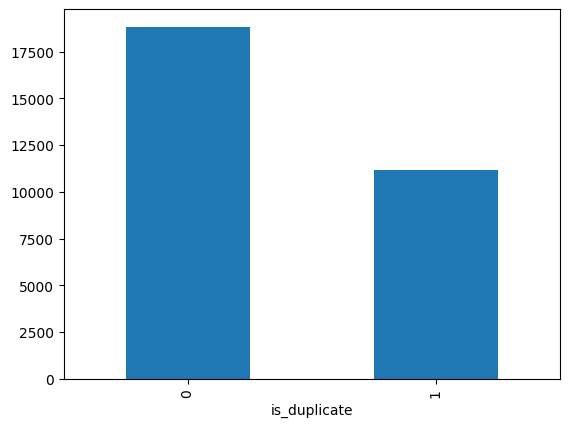

In [31]:
print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [32]:
# Repeaated Questions
qid=pd.Series(new_df['qid1'].tolist()+new_df['qid2'].tolist())
print('Number Of Unique questions',np.unique(qid).shape[0])
x=qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number Of Unique questions 55321
Number of questions getting repeated 3468


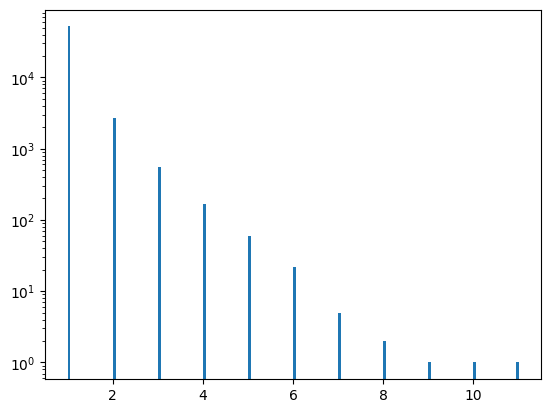

In [33]:
# Repeated Question histogram
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [34]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()


In [35]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
150055,150055,20244,43017,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?,1,53,49
238386,238386,75823,153560,What are some amazing engineering facts in the...,What are some interesting things about Indian ...,1,63,55
72203,72203,124109,124110,How can I raise funding for my short film?,How can one get funding for short films?,1,42,40
178599,178599,274261,8500,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?,1,38,45
216491,216491,33250,48725,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...,1,52,71


In [36]:
new_df['q1_num_words']=new_df['question1'].apply(lambda row:len(row.split(" ")))
new_df['q2_num_words']=new_df['question2'].apply(lambda row:len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
150055,150055,20244,43017,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?,1,53,49,9,8
238386,238386,75823,153560,What are some amazing engineering facts in the...,What are some interesting things about Indian ...,1,63,55,10,8
72203,72203,124109,124110,How can I raise funding for my short film?,How can one get funding for short films?,1,42,40,9,8
178599,178599,274261,8500,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?,1,38,45,7,7
216491,216491,33250,48725,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...,1,52,71,10,14


In [37]:
def common_words(row):
    w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
    return len(w1 & w2)

In [38]:
new_df['word_common']=new_df.apply(common_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
150055,150055,20244,43017,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?,1,53,49,9,8,6
238386,238386,75823,153560,What are some amazing engineering facts in the...,What are some interesting things about Indian ...,1,63,55,10,8,5
72203,72203,124109,124110,How can I raise funding for my short film?,How can one get funding for short films?,1,42,40,9,8,5
178599,178599,274261,8500,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?,1,38,45,7,7,4
216491,216491,33250,48725,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...,1,52,71,10,14,3


In [39]:
def total_words(row):
  w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
  w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
  return (len(w1) + len(w2))

In [40]:
new_df['word_total']=new_df.apply(total_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
150055,150055,20244,43017,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?,1,53,49,9,8,6,17
238386,238386,75823,153560,What are some amazing engineering facts in the...,What are some interesting things about Indian ...,1,63,55,10,8,5,18
72203,72203,124109,124110,How can I raise funding for my short film?,How can one get funding for short films?,1,42,40,9,8,5,17
178599,178599,274261,8500,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?,1,38,45,7,7,4,14
216491,216491,33250,48725,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...,1,52,71,10,14,3,21


In [41]:
new_df['word_share']=round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
150055,150055,20244,43017,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?,1,53,49,9,8,6,17,0.35
238386,238386,75823,153560,What are some amazing engineering facts in the...,What are some interesting things about Indian ...,1,63,55,10,8,5,18,0.28
72203,72203,124109,124110,How can I raise funding for my short film?,How can one get funding for short films?,1,42,40,9,8,5,17,0.29
178599,178599,274261,8500,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?,1,38,45,7,7,4,14,0.29
216491,216491,33250,48725,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...,1,52,71,10,14,3,21,0.14


minimum characters  4
maximum characters  315
average characters  59


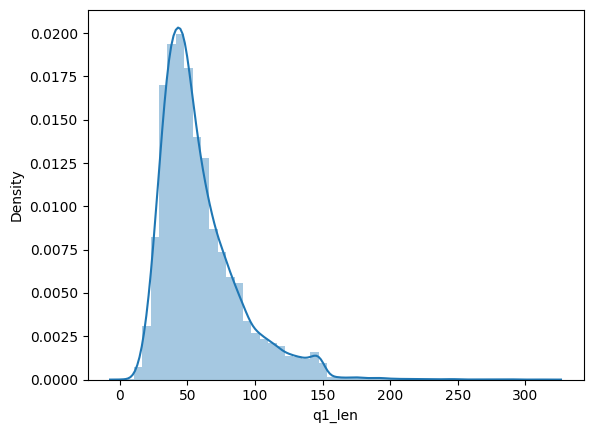

In [42]:
## Analysis Of features
sns.distplot(new_df['q1_len'])
print('minimum characters ',new_df['q1_len'].min())
print('maximum characters ',new_df['q1_len'].max())
print('average characters ',int(new_df['q1_len'].mean()))

minimum characters  2
maximum characters  1151
average characters  60


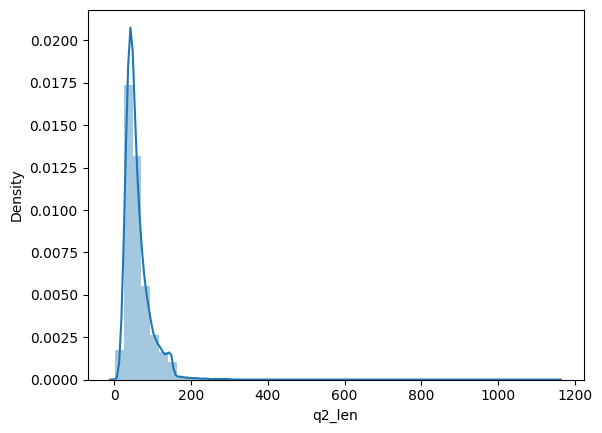

In [43]:
## Analysis Of features
sns.distplot(new_df['q2_len'])
print('minimum characters ',new_df['q2_len'].min())
print('maximum characters ',new_df['q2_len'].max())
print('average characters ',int(new_df['q2_len'].mean()))

minimum characters  1
maximum characters  59
average characters  10


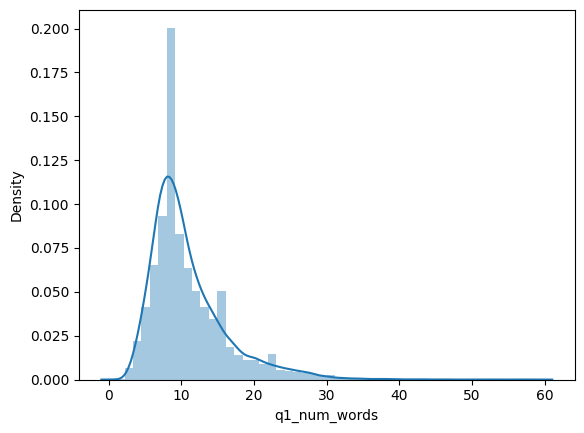

In [44]:
## Analysis Of features
sns.distplot(new_df['q1_num_words'])
print('minimum characters ',new_df['q1_num_words'].min())
print('maximum characters ',new_df['q1_num_words'].max())
print('average characters ',int(new_df['q1_num_words'].mean()))

minimum characters  1
maximum characters  237
average characters  11


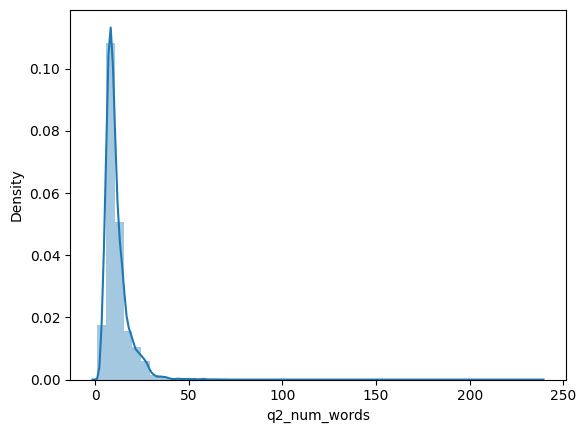

In [45]:
## Analysis Of features
sns.distplot(new_df['q2_num_words'])
print('minimum characters ',new_df['q2_num_words'].min())
print('maximum characters ',new_df['q2_num_words'].max())
print('average characters ',int(new_df['q2_num_words'].mean()))

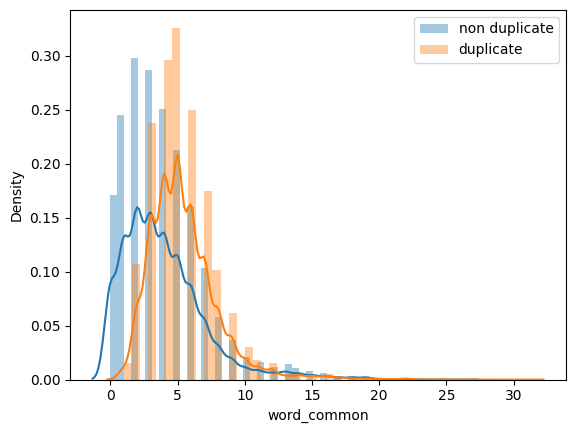

In [46]:
## Common words
sns.distplot(new_df[new_df['is_duplicate']==0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate']==1]['word_common'],label='duplicate')
plt.legend()
plt.show()

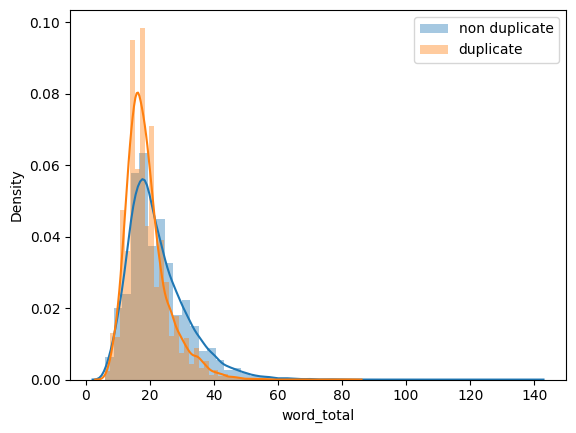

In [47]:
## Common words
sns.distplot(new_df[new_df['is_duplicate']==0]['word_total'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate']==1]['word_total'],label='duplicate')
plt.legend()
plt.show()

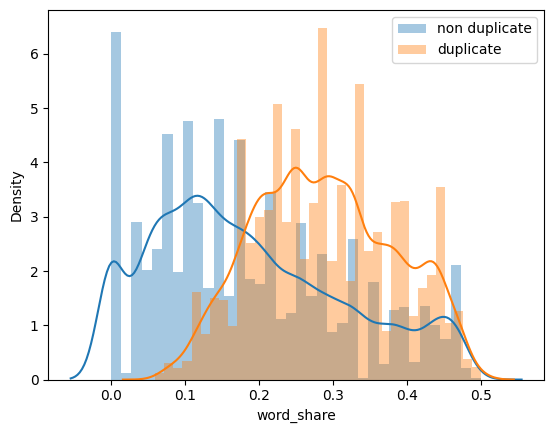

In [48]:
## Common words
sns.distplot(new_df[new_df['is_duplicate']==0]['word_share'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate']==1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [49]:
ques_df=new_df[['question1','question2']]
ques_df.head()

,question1,question2
150055,What are some of your favorite documentaries a...,What are your favorite documentaries of all time?
238386,What are some amazing engineering facts in the...,What are some interesting things about Indian ...
72203,How can I raise funding for my short film?,How can one get funding for short films?
178599,How do I become the perfect boyfriend?,How would you describe the perfect boyfriend?
216491,What are the Hollywood movies that are a must ...,Can you provide me the list of the best hollyw...


In [52]:
final_df=new_df.drop(columns=['id','qid1','qid2','question1','question2',])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
150055,1,53,49,9,8,6,17,0.35
238386,1,63,55,10,8,5,18,0.28
72203,1,42,40,9,8,5,17,0.29
178599,1,38,45,7,7,4,14,0.29
216491,1,52,71,10,14,3,21,0.14


In [53]:
final_df.shape

(30000, 8)

In [54]:
## Apply Bag Of Word
from sklearn.feature_extraction.text import CountVectorizer
#merger texts
questions=list(ques_df['question1'])+list(ques_df['question2'])
cv=CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [55]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [56]:
final_df=pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,...,2960,2961,2962,2963,2964,2965,2966,2967,2968,2969,2970,2971,2972,2973,2974,2975,2976,2977,2978,2979,2980,2981,2982,2983,2984,2985,2986,2987,2988,2989,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
150055,1,53,49,9,8,6,17,0.35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
238386,1,63,55,10,8,5,18,0.28,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
72203,1,42,40,9,8,5,17,0.29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
178599,1,38,45,7,7,4,14,0.29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
216491,1,52,71,10,14,3,21,0.14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.774

In [59]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)


0.7653333333333333

***After the feature by adding 7 col like q1 q1 q1_len,,q2_len,word_total....etc we train on the model and Found that RandomForestClassifier give best accuracy that is 77.4%.***

# Advanced Features

## 1. Token Features

- **cwc_min**: This is the ratio of the number of common words to the length of the smaller question.
- **cwc_max**: This is the ratio of the number of common words to the length of the larger question.
- **csc_min**: This is the ratio of the number of common stop words to the smaller stop word count among the two questions.
- **csc_max**: This is the ratio of the number of common stop words to the larger stop word count among the two questions.
- **ctc_min**: This is the ratio of the number of common tokens to the smaller token count among the two questions.
- **ctc_max**: This is the ratio of the number of common tokens to the larger token count among the two questions.
- **last_word_eq**: 1 if the last word in the two questions is the same, 0 otherwise.
- **first_word_eq**: 1 if the first word in the two questions is the same, 0 otherwise.

## 2. Length Based Features

- **mean_len**: Mean of the length of the two questions (number of words).
- **abs_len_diff**: Absolute difference between the length of the two questions (number of words).
- **longest_substr_ratio**: Ratio of the length of the longest substring among the two questions to the length of the smaller question.

## 3. Fuzzy Features

- **fuzz_ratio**: `fuzz_ratio` score from fuzzywuzzy.
- **fuzz_partial_ratio**: `fuzz_partial_ratio` from fuzzywuzzy.
- **token_sort_ratio**: `token_sort_ratio` from fuzzywuzzy.
- **token_set_ratio**: `token_set_ratio` from fuzzywuzzy.